In [1]:
import mdtraj as md
import numpy as np
from itertools import combinations
import os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

import matplotlib.pyplot as plt

# load .pdb and create tICs

In [2]:
top_pdb = "FIP35ww-full-src\\fip35ww.pdb"
dir_0 = "FIP35ww-full-src\\GTT-0-c-alpha-xtc\\GTT-0-c-alpha-"
dir_1 = "FIP35ww-full-src\\GTT-1-c-alpha-xtc\\GTT-1-c-alpha-"

pairs = np.array(list(combinations(range(35), 2)))
featurizer = AtomPairsFeaturizer(pair_indices=pairs, periodic=True)

features = []
traj_lens = []
sub_sam = 5

for i in range(25+33):
    if i < 25:
        traj = md.load(dir_0 + f'{i:03d}.xtc', top=top_pdb, stride=sub_sam)
    else:
        traj = md.load(dir_1 + f'{i-25:03d}.xtc', top=top_pdb, stride=sub_sam)
    X = featurizer.transform([traj])[0]
    features.append(X)
    traj_lens.append(X.shape[0])
    print(f'{i} [{traj.n_frames}]', end=' ')
    if i % 8 == 0 and i != 0:
        print()

0 [20000] 1 [20000] 2 [20000] 3 [20000] 4 [20000] 5 [20000] 6 [20000] 7 [20000] 8 [20000] 
9 [20000] 10 [20000] 11 [20000] 12 [20000] 13 [20000] 14 [20000] 15 [20000] 16 [20000] 
17 [20000] 18 [20000] 19 [20000] 20 [20000] 21 [20000] 22 [20000] 23 [20000] 24 [6518] 
25 [20000] 26 [20000] 27 [20000] 28 [20000] 29 [20000] 30 [20000] 31 [20000] 32 [20000] 
33 [20000] 34 [20000] 35 [20000] 36 [20000] 37 [20000] 38 [20000] 39 [20000] 40 [20000] 
41 [20000] 42 [20000] 43 [20000] 44 [20000] 45 [20000] 46 [20000] 47 [20000] 48 [20000] 
49 [20000] 50 [20000] 51 [20000] 52 [20000] 53 [20000] 54 [20000] 55 [20000] 56 [20000] 
57 [10826] 

In [9]:
print(sum(traj_lens))
print(traj_lens)

1137344
[20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 6518, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 10826]


In [4]:
tica_model = msm_tICA(lag_time=10, n_components=5)
tica_trajs = tica_model.fit_transform(features)

In [5]:
# sub_sam = 5 = 1 ns, lag_time = 10 ns
print(tica_model.eigenvalues_)
print(tica_model.timescales_)

[0.99358702 0.8485559  0.80594582 0.78645776 0.72655325]
[1554.33309745   60.89417849   46.35235699   41.62915509   31.30444053]


In [8]:
print(len(tica_trajs))
print(tica_trajs[0].shape)
tics_of_trajs = np.array(tica_trajs)
print(tics_of_trajs.shape)

58
(20000, 5)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (58,) + inhomogeneous part.

In [9]:
GTT0 = np.concatenate(tica_trajs[:25], axis=0)
GTT1 = np.concatenate(tica_trajs[25:], axis=0)
print(GTT0.shape, GTT1.shape)

(486518, 5) (650826, 5)


In [11]:
np.savez("FIP35-tICA.npz", GTT0=GTT0[:, :3], GTT1=GTT1[:, :3])

# tICA plotting

In [10]:
load_data_from_npz = np.load("FIP35-tICA.npz")
tics_of_trajs = np.concatenate([load_data_from_npz['GTT0'], load_data_from_npz['GTT1']], axis=0)
tics_of_trajs.shape

(1137344, 3)

In [11]:
basis_list = np.array([[[-0.5402968893832484, 2], [1.6977050721019225, 2]], [[0.03775098344108225, 2], [-0.11639949878185235, 2]], [[0.011024319620013722, 2], [-0.031054131813476105, 2]]])
basis_list

array([[[-0.54029689,  2.        ],
        [ 1.69770507,  2.        ]],

       [[ 0.03775098,  2.        ],
        [-0.1163995 ,  2.        ]],

       [[ 0.01102432,  2.        ],
        [-0.03105413,  2.        ]]])

In [12]:
from matplotlib.patches import Ellipse
from sklearn.neighbors import NearestNeighbors

pts = np.vstack([tics_of_trajs[:, 0], tics_of_trajs[:, 1]]).T

nbrs = NearestNeighbors(n_neighbors=10).fit(pts)
dist, _ = nbrs.kneighbors(pts)

density = 1 / (dist[:, -1] + 1e-6)

In [15]:
print(np.max(density), np.min(density))
den_log_01 = np.log10(density)
den_log_01[den_log_01 < 2.5] = 0
den_log_01 = den_log_01 * 3 - 5

10476.86541148086 2.0604441150493678


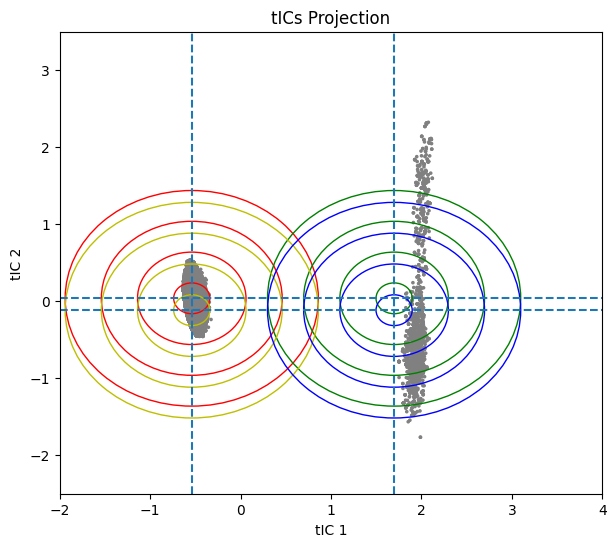

In [22]:
fig, ax = plt.subplots(figsize=(7,6))
plt.scatter(tics_of_trajs[:, 0], tics_of_trajs[:, 1], color='gray', s=den_log_01)
plt.axvline(basis_list[0, 0, 0], linestyle="--")
plt.axvline(basis_list[0, 1, 0], linestyle="--")
plt.axhline(basis_list[1, 0, 0], linestyle="--")
plt.axhline(basis_list[1, 1, 0], linestyle="--")

# 50% percentile = .5*1.349*sigma, 68%=sigma
color_l = ['r', 'g', 'y', 'b']
for i in range(4):
    for j in [.1, .3, .5, .7]:
        oval = Ellipse((basis_list[0, i%2, 0], basis_list[1, i//2, 0]), width=4*j, height=4*j, color = color_l[i], fill=False)
        ax.add_patch(oval)

plt.xlim([-2, 4])
plt.ylim([-2.5, 3.5])

plt.xlabel('tIC 1')
plt.ylabel('tIC 2')
plt.title('tICs Projection')
plt.show()

In [37]:
pts = np.vstack([tics_of_trajs[:, 0], tics_of_trajs[:, 2]]).T
nbrs = NearestNeighbors(n_neighbors=10).fit(pts)
dist, _ = nbrs.kneighbors(pts)
density = 1 / (dist[:, -1] + 1e-6)

print(np.max(density), np.min(density))
den_log_02 = np.log10(density)
den_log_02[den_log_02 < 2.5] = 0
den_log_02 = den_log_02 * 2 - 4

12426.265036530975 0.9772224626367567


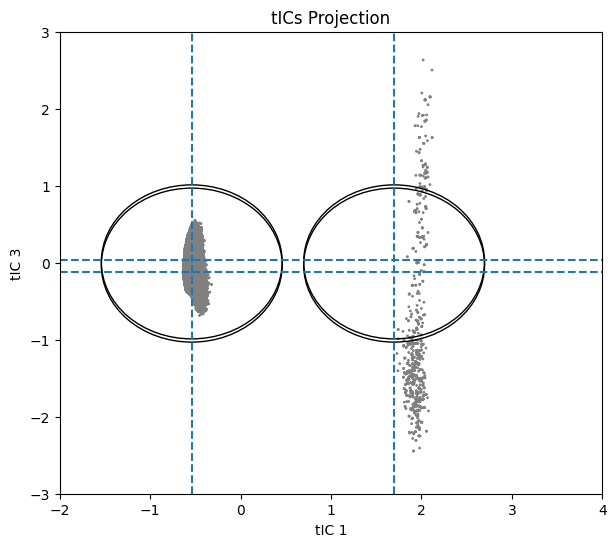

In [39]:
fig, ax = plt.subplots(figsize=(7,6))
plt.scatter(tics_of_trajs[:, 0], tics_of_trajs[:, 2], color='gray', s=den_log_02)
plt.axvline(basis_list[0, 0, 0], linestyle="--")
plt.axvline(basis_list[0, 1, 0], linestyle="--")
plt.axhline(basis_list[1, 0, 0], linestyle="--")
plt.axhline(basis_list[1, 1, 0], linestyle="--")

# 50% percentile = .5*1.349*sigma
oval = Ellipse((basis_list[0, 0, 0], basis_list[2, 0, 0]), width=2, height=2, fill=False)
ax.add_patch(oval)
oval = Ellipse((basis_list[0, 1, 0], basis_list[2, 0, 0]), width=2, height=2, fill=False)
ax.add_patch(oval)
oval = Ellipse((basis_list[0, 0, 0], basis_list[2, 1, 0]), width=2, height=2, fill=False)
ax.add_patch(oval)
oval = Ellipse((basis_list[0, 1, 0], basis_list[2, 1, 0]), width=2, height=2, fill=False)
ax.add_patch(oval)
plt.xlim([-2, 4])
plt.ylim([-3, 3])

plt.xlabel('tIC 1')
plt.ylabel('tIC 3')
plt.title('tICs Projection')
plt.show()

In [29]:
print(np.max(np.log(density)), np.min(np.log(density)))


9.256924811177187 0.7229215493951321


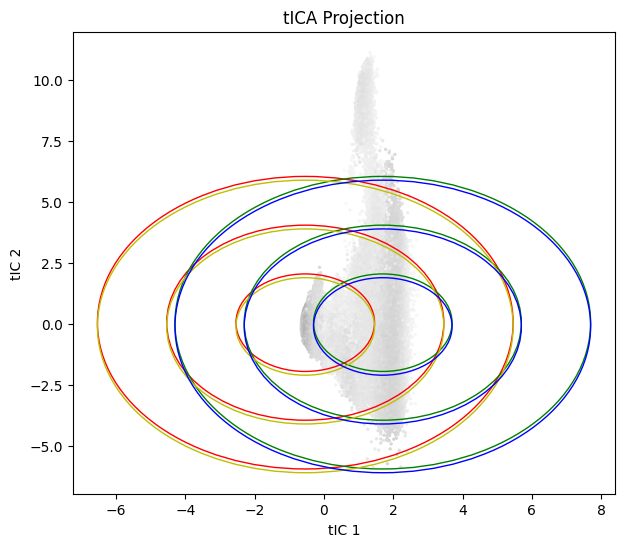

In [32]:
fig, ax = plt.subplots(figsize=(7,6))
#norm = colors.TwoSlopeNorm(vmin=-.0018, vcenter=0, vmax=.0005)
plt.scatter(tics_of_trajs[:, 0], tics_of_trajs[:, 2], vmin=0, vmax=15, c=np.log(density), s=2, cmap="Greys")
color_l = ['r', 'g', 'y', 'b']
for i in range(4):
    for j in [1,2,3]:#[.1, .3, .5, .7]:
        oval = Ellipse((basis_list[0, i%2, 0], basis_list[1, i//2, 0]), width=4*j, height=4*j, color = color_l[i], fill=False)
        ax.add_patch(oval)
plt.xlabel('tIC 1')
plt.ylabel('tIC 2')
plt.title('tICA Projection')
plt.show()

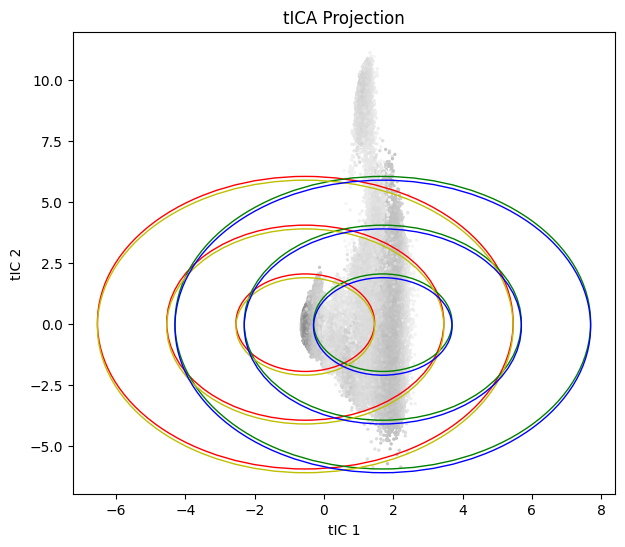

In [33]:
fig, ax = plt.subplots(figsize=(7,6))
#norm = colors.TwoSlopeNorm(vmin=-.0018, vcenter=0, vmax=.0005)
plt.scatter(tics_of_trajs[:, 0], tics_of_trajs[:, 2], vmin=0, vmax=15, c=np.log(density), s=2, cmap="Greys")
color_l = ['r', 'g', 'y', 'b']
for i in range(4):
    for j in [1,2,3]:#[.1, .3, .5, .7]:
        oval = Ellipse((basis_list[0, i%2, 0], basis_list[1, i//2, 0]), width=4*j, height=4*j, color = color_l[i], fill=False)
        ax.add_patch(oval)
plt.xlabel('tIC 1')
plt.ylabel('tIC 2')
plt.title('tICA Projection')
plt.show()

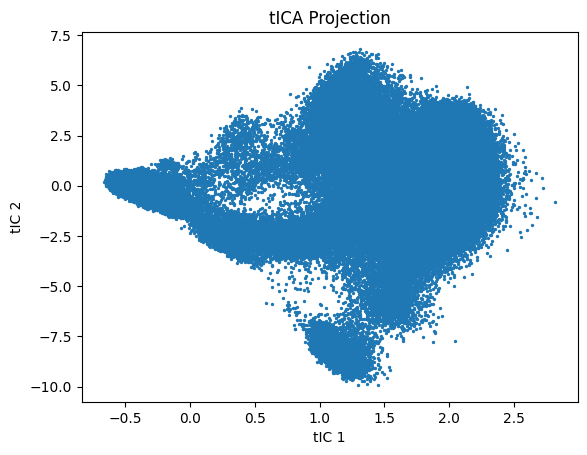

In [35]:
plt.scatter(tics_of_trajs[:, 0], tics_of_trajs[:, 1], s=2)
plt.xlabel('tIC 1')
plt.ylabel('tIC 2')
plt.title('tICA Projection')
plt.show()

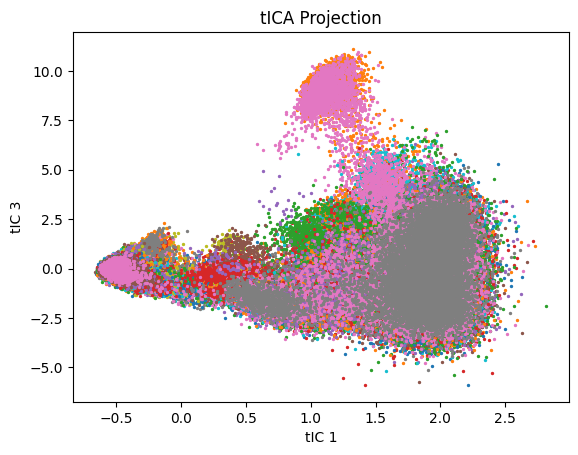

In [22]:
for i in range(len(tica_trajs)):
    plt.scatter(tics_of_trajs[:, 0], tica_trajs[i][:, 2], s=2)
plt.xlabel('tIC 1')
plt.ylabel('tIC 3')
plt.title('tICA Projection')
plt.show()

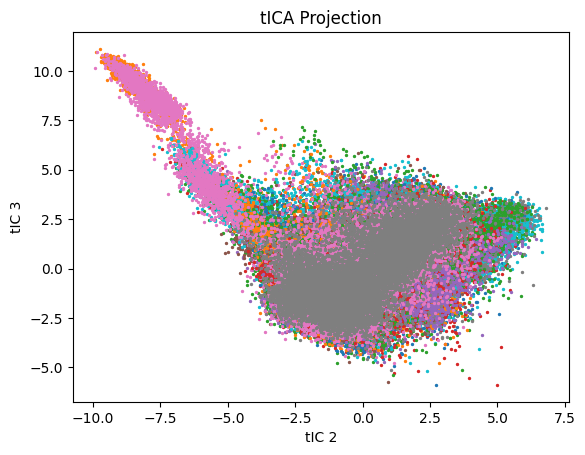

In [23]:
for i in range(len(tica_trajs)):
    plt.scatter(tica_trajs[i][:, 1], tica_trajs[i][:, 2], s=2)
plt.xlabel('tIC 2')
plt.ylabel('tIC 3')
plt.title('tICA Projection')
plt.show()

# RMSD

In [38]:
rmsd1 = []
for i in range(25+33):
    if i < 25:
        txt_name = f"rmsd-beta1\\GTT-0-c-alpha-{i:03d}.txt"
    else:
        txt_name = f"rmsd-beta1\\GTT-1-c-alpha-{i-25:03d}.txt"
    data = np.loadtxt(txt_name)
    rmsd1.append(data[::sub_sam, 1]) # sub_sam = 5
    print(f'{i} [{rmsd1[-1].shape}]', end='')
    if i % 8 == 0 and i != 0:
        print()

print('#')

rmsd2 = []
for i in range(25+33):
    if i < 25:
        txt_name = f"rmsd-beta2\\GTT-0-c-alpha-{i:03d}.txt"
    else:
        txt_name = f"rmsd-beta2\\GTT-1-c-alpha-{i-25:03d}.txt"
    data = np.loadtxt(txt_name)
    rmsd2.append(data[::sub_sam, 1]) # sub_sam = 5
    print(f'{i} [{rmsd2[-1].shape}]', end='')
    if i % 8 == 0 and i != 0:
        print()

0 [(20000,)]1 [(20000,)]2 [(20000,)]3 [(20000,)]4 [(20000,)]5 [(20000,)]6 [(20000,)]7 [(20000,)]8 [(20000,)]
9 [(20000,)]10 [(20000,)]11 [(20000,)]12 [(20000,)]13 [(20000,)]14 [(20000,)]15 [(20000,)]16 [(20000,)]
17 [(20000,)]18 [(20000,)]19 [(20000,)]20 [(20000,)]21 [(20000,)]22 [(20000,)]23 [(20000,)]24 [(6518,)]
25 [(20000,)]26 [(20000,)]27 [(20000,)]28 [(20000,)]29 [(20000,)]30 [(20000,)]31 [(20000,)]32 [(20000,)]
33 [(20000,)]34 [(20000,)]35 [(20000,)]36 [(20000,)]37 [(20000,)]38 [(20000,)]39 [(20000,)]40 [(20000,)]
41 [(20000,)]42 [(20000,)]43 [(20000,)]44 [(20000,)]45 [(20000,)]46 [(20000,)]47 [(20000,)]48 [(20000,)]
49 [(20000,)]50 [(20000,)]51 [(20000,)]52 [(20000,)]53 [(20000,)]54 [(20000,)]55 [(20000,)]56 [(20000,)]
57 [(10826,)]#
0 [(20000,)]1 [(20000,)]2 [(20000,)]3 [(20000,)]4 [(20000,)]5 [(20000,)]6 [(20000,)]7 [(20000,)]8 [(20000,)]
9 [(20000,)]10 [(20000,)]11 [(20000,)]12 [(20000,)]13 [(20000,)]14 [(20000,)]15 [(20000,)]16 [(20000,)]
17 [(20000,)]18 [(20000,)]19 [(2000

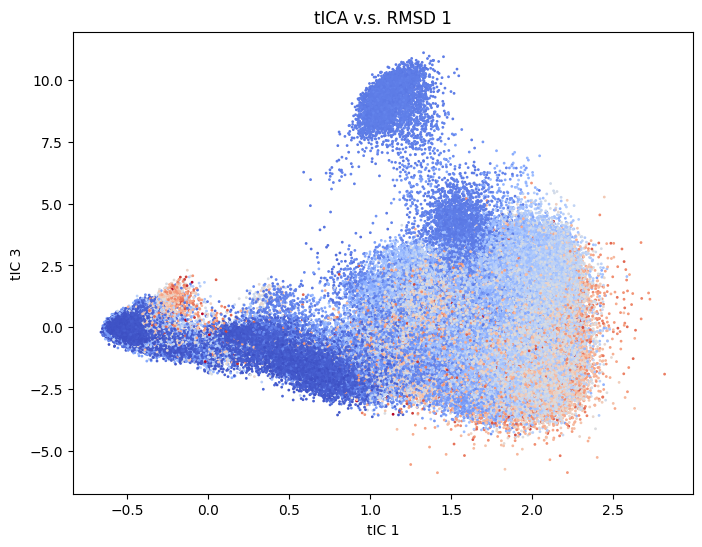

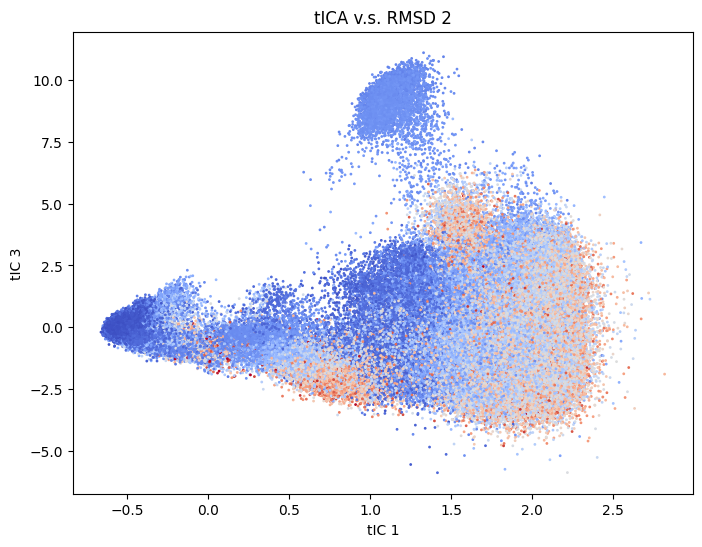

In [45]:
plt.figure(figsize=(8,6))
for i in range(len(tica_trajs)):
    plt.scatter(tica_trajs[i][:, 0], tica_trajs[i][:, 2], s=1, c=rmsd1[i], cmap="coolwarm")
plt.xlabel('tIC 1')
plt.ylabel('tIC 3')
plt.title('tICA v.s. RMSD 1')
plt.show()
plt.figure(figsize=(8,6))
for i in range(len(tica_trajs)):
    plt.scatter(tica_trajs[i][:, 0], tica_trajs[i][:, 2], s=1, c=rmsd2[i], cmap="coolwarm")
plt.xlabel('tIC 1')
plt.ylabel('tIC 3')
plt.title('tICA v.s. RMSD 2')
plt.show()

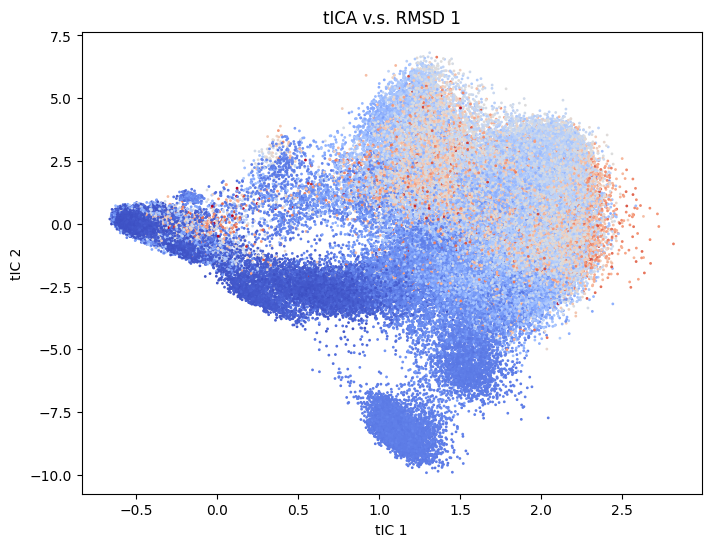

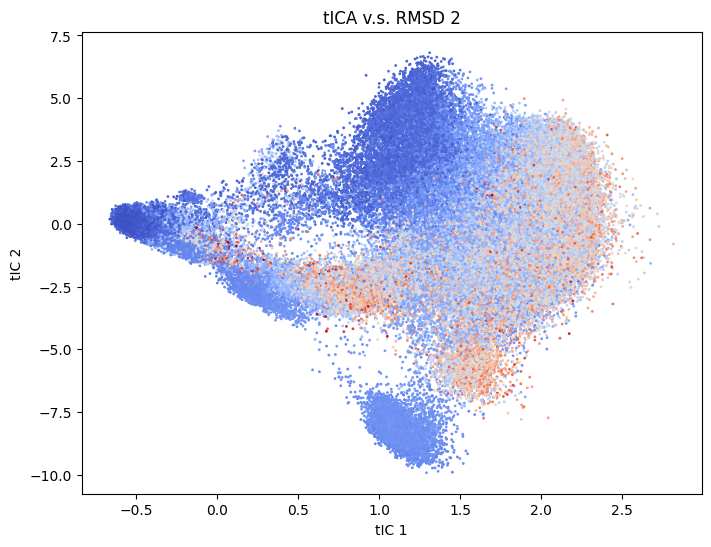

In [46]:
plt.figure(figsize=(8,6))
for i in range(len(tica_trajs)):
    plt.scatter(tica_trajs[i][:, 0], tica_trajs[i][:, 1], s=1, c=rmsd1[i], cmap="coolwarm")
plt.xlabel('tIC 1')
plt.ylabel('tIC 2')
plt.title('tICA v.s. RMSD 1')
plt.show()
plt.figure(figsize=(8,6))
for i in range(len(tica_trajs)):
    plt.scatter(tica_trajs[i][:, 0], tica_trajs[i][:, 1], s=1, c=rmsd2[i], cmap="coolwarm")
plt.xlabel('tIC 1')
plt.ylabel('tIC 2')
plt.title('tICA v.s. RMSD 2')
plt.show()